In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\Kunal\Downloads\seasonal_agriculture_performance_dataset.csv")

# Display first 5 records
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
#  dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


In [7]:
# Display all column names

print(df.columns)

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')


In [8]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
# Count missing values in each column

print(df.isnull().sum())

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [10]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
pd.set_option('display.max_columns', None)
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [13]:
# Check missing values

missing = df.isnull().sum()

print(missing[missing > 0])

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [14]:
# Percentage of missing values

missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent[missing_percent > 0])

Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [15]:
# Statistical summary of numerical columns

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [17]:
# Fill missing values using median

df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].median()
)

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [18]:
# Check missing values again

print(df.isnull().sum().sum())

0


In [19]:
print("Rainfall missing:", df['Rainfall_mm'].isnull().sum())
print("Soil Moisture missing:", df['Soil_Moisture_pct'].isnull().sum())
print("Yield missing:", df['Yield_Tonnes_Ha'].isnull().sum())

Rainfall missing: 0
Soil Moisture missing: 0
Yield missing: 0


In [20]:
# Season distribution

print(df['Season'].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


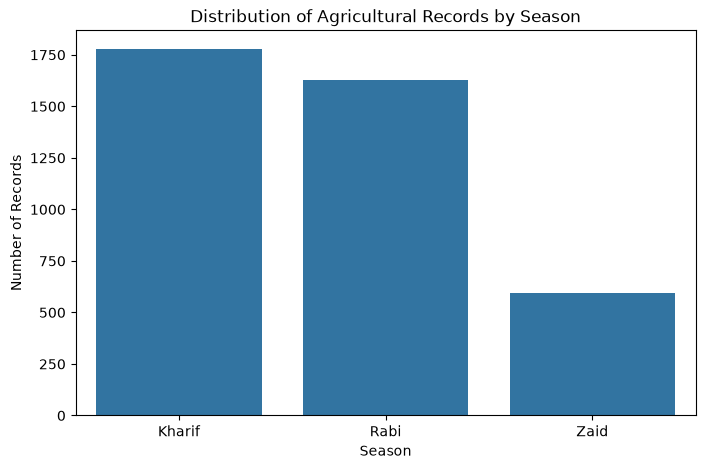

In [22]:
# Visualize season distribution
#How many agricultural records are available for Kharif, Rabi, and Zaid seasons?
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Season')

plt.title('Distribution of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.show()



In [23]:
# Calculate average yield for each season

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

print(season_yield)

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


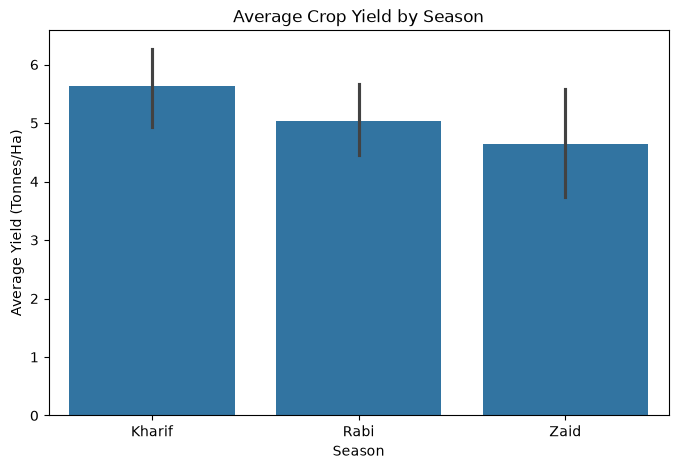

In [24]:
# Average yield by season
#Which season has the highest average agricultural yield?
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [25]:
# Exact average yield by season

season_yield = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

print(season_yield)

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


## Crop-wise Analysis

Crop-wise analysis is performed to compare the productivity
and total production of different crops. Average yield is used
to evaluate productivity per hectare, while total production
is used to understand the overall contribution of each crop.

In [26]:
# Calculate average yield for each crop
#Which crops have the highest average yield?
crop_yield = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

print(crop_yield)

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


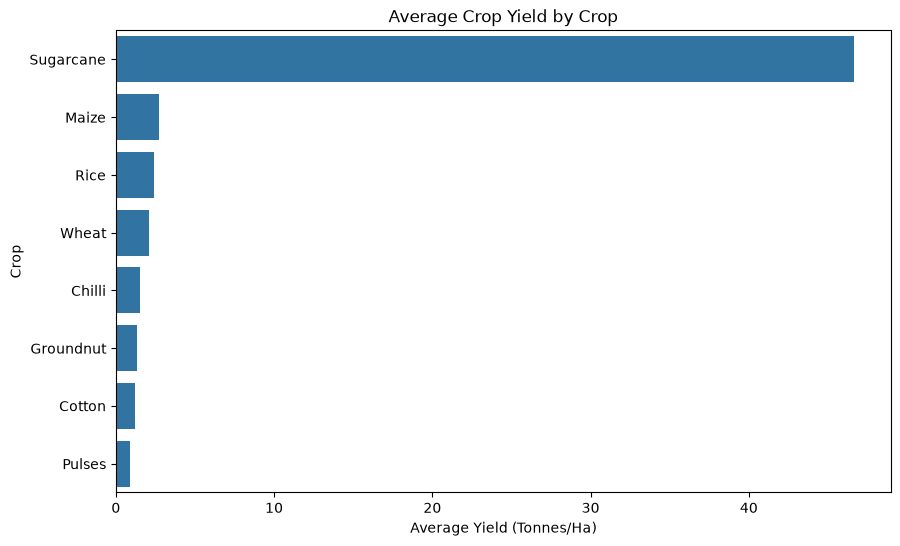

In [27]:
# Average yield by crop

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title('Average Crop Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.show()

In [28]:
# Total production by crop
#Then calculate total production by crop
crop_production = (
    df.groupby('Crop')['Production_Tonnes']
    .sum()
    .sort_values(ascending=False)
)

print(crop_production)

Crop
Sugarcane    119685.97
Rice          13309.15
Maize         12001.40
Wheat         10348.30
Chilli         5101.75
Cotton         4773.10
Groundnut      4094.07
Pulses         3671.10
Name: Production_Tonnes, dtype: float64


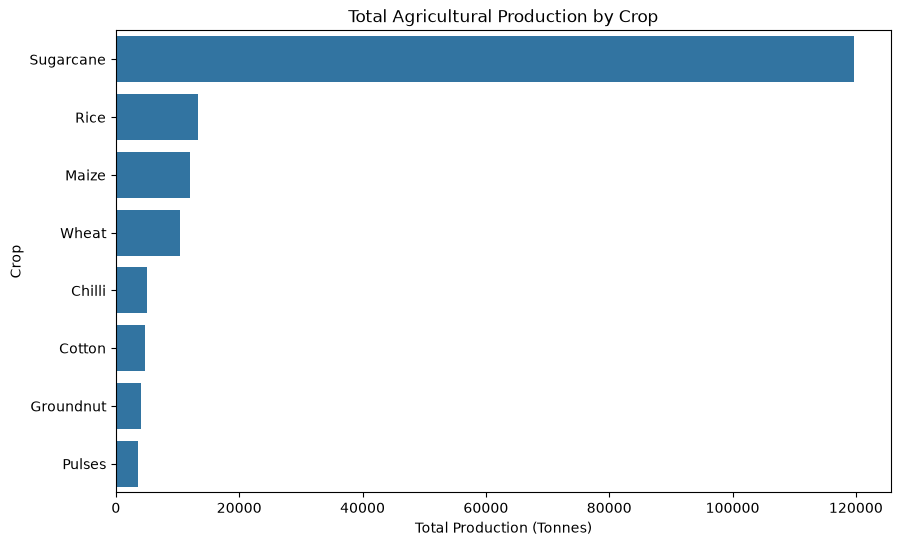

In [29]:
# Total production by crop

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_production.values,
    y=crop_production.index
)

plt.title('Total Agricultural Production by Crop')
plt.xlabel('Total Production (Tonnes)')
plt.ylabel('Crop')

plt.show()

## Economic Performance Analysis

Economic performance is analyzed using profit to compare
the financial outcomes of different seasons and crops.
Average profit is calculated to identify which seasons and
crops provide better economic performance.

In [30]:
# Calculate average profit by season

season_profit = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


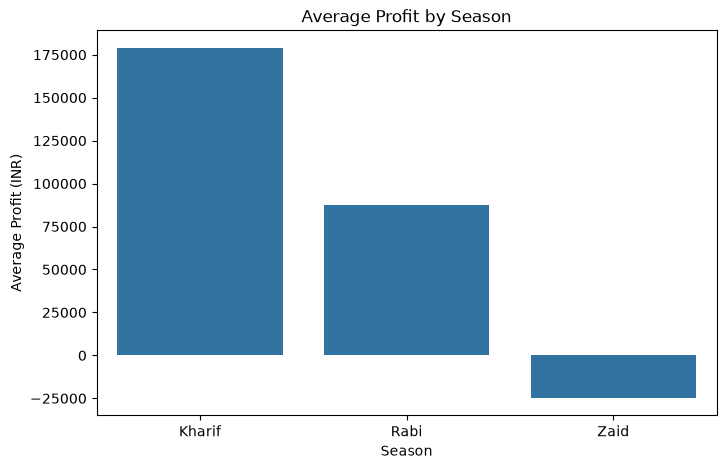

In [31]:
# Average profit by season

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

In [32]:
# Calculate average profit by crop

crop_profit = (
    df.groupby('Crop')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print(crop_profit)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


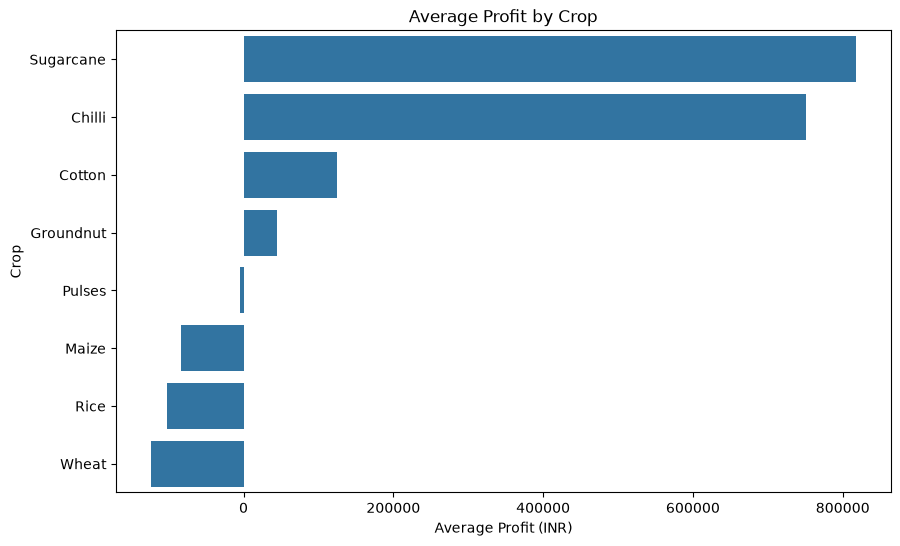

In [33]:
# Average profit by crop

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_profit.values,
    y=crop_profit.index
)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

plt.show()

## Irrigation and Water Efficiency Analysis

This analysis compares different irrigation methods based on
water usage and water efficiency. The objective is to understand
how irrigation practices are associated with efficient use of
water resources.

In [34]:
# Average water usage by irrigation method

water_usage = (
    df.groupby('Irrigation_Method')['Water_Used_m3']
    .mean()
    .sort_values(ascending=False)
)

print(water_usage)

Irrigation_Method
Flood        8026.472519
Sprinkler    6208.258856
Drip         5918.747541
Rainfed      3549.554275
Name: Water_Used_m3, dtype: float64


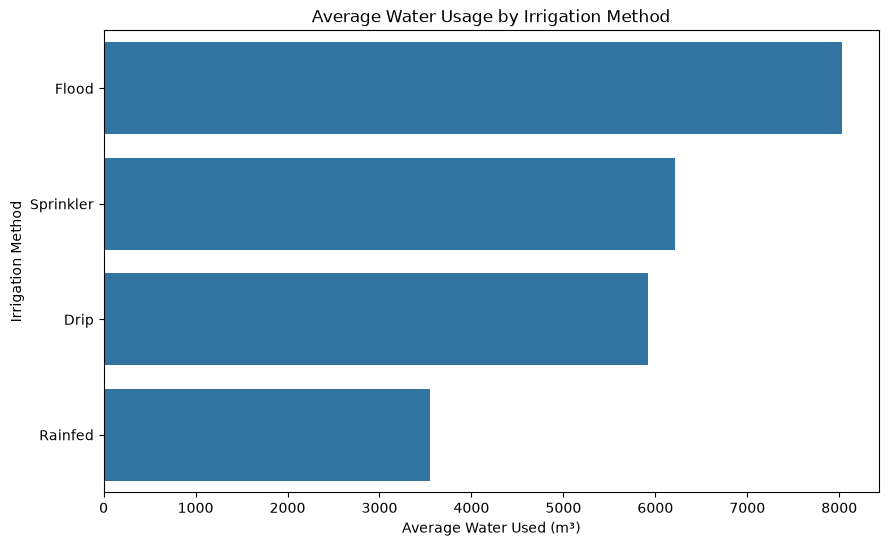

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=water_usage.values,
    y=water_usage.index
)

plt.title('Average Water Usage by Irrigation Method')
plt.xlabel('Average Water Used (m³)')
plt.ylabel('Irrigation Method')

plt.show()

In [36]:
# Average water efficiency by irrigation method

water_efficiency = (
    df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3']
    .mean()
    .sort_values(ascending=False)
)

print(water_efficiency)

Irrigation_Method
Rainfed      7.563784
Drip         6.267129
Sprinkler    4.669805
Flood        3.438853
Name: Water_Efficiency_t_per_1000m3, dtype: float64


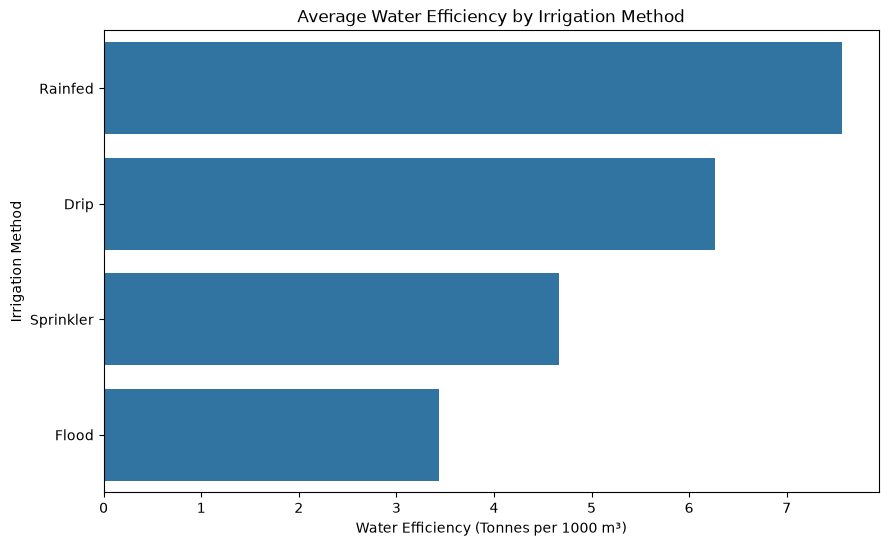

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=water_efficiency.values,
    y=water_efficiency.index
)

plt.title('Average Water Efficiency by Irrigation Method')
plt.xlabel('Water Efficiency (Tonnes per 1000 m³)')
plt.ylabel('Irrigation Method')

plt.show()

## Rainfall and Crop Yield Analysis

The relationship between rainfall and crop yield is analyzed
using correlation analysis and a scatter plot. This helps
determine whether changes in rainfall are associated with
changes in agricultural yield.

In [38]:
# Correlation between rainfall and yield

correlation = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Rainfall and Yield:", correlation)

Correlation between Rainfall and Yield: 0.030950993551650877


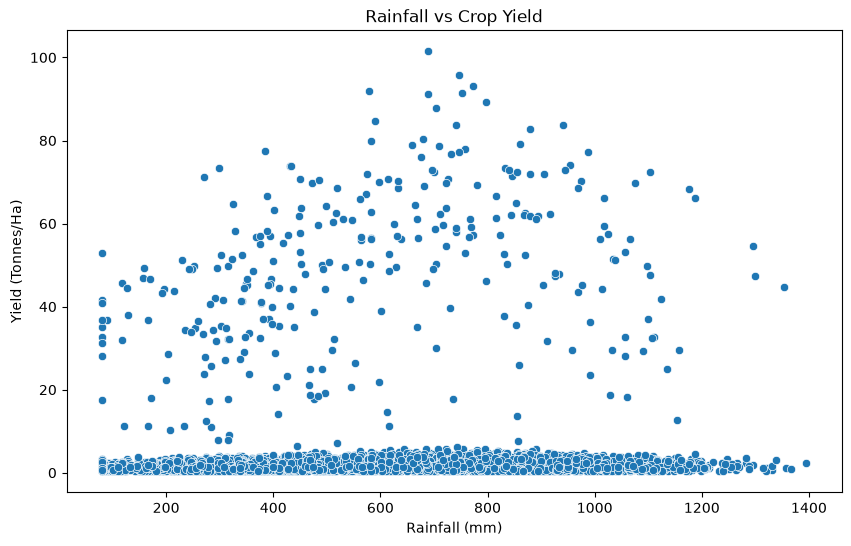

In [39]:
# Rainfall vs Crop Yield

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

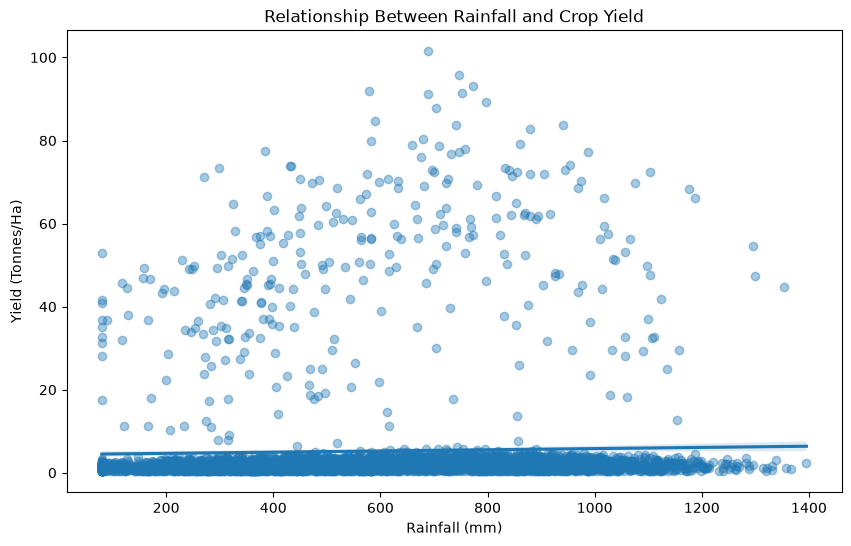

In [40]:
# Rainfall vs Crop Yield with trend line

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

## Correlation Analysis

Correlation analysis is used to examine the relationships
between numerical agricultural variables. A correlation
coefficient ranges from -1 to +1, where values closer to
+1 indicate a positive relationship, values closer to -1
indicate a negative relationship, and values near 0 indicate
a weak linear relationship.

The analysis focuses particularly on relationships with
crop yield and profit.

In [41]:
# Select numerical columns

numeric_df = df.select_dtypes(include='number')

# Calculate correlation matrix

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                               Farm_Area_Hectares  Rainfall_mm  \
Farm_Area_Hectares                       1.000000     0.007256   
Rainfall_mm                              0.007256     1.000000   
Avg_Temperature_C                        0.036870     0.198492   
Humidity_pct                             0.000471     0.521069   
Sunlight_Hours_Day                       0.001821    -0.362779   
Soil_pH                                  0.009857     0.016657   
Soil_Moisture_pct                        0.004033     0.508941   
Nitrogen_kg_ha                           0.013658     0.007460   
Phosphorus_kg_ha                        -0.006625     0.020940   
Potassium_kg_ha                          0.000195     0.031373   
Fertilizer_kg_ha                         0.014975     0.024602   
Pesticide_Litre_ha                      -0.005207     0.004058   
Seed_Quality_Score                       0.015236    -0.018581   
Yield_Tonnes_Ha                          0.030203     0.030951   
Production

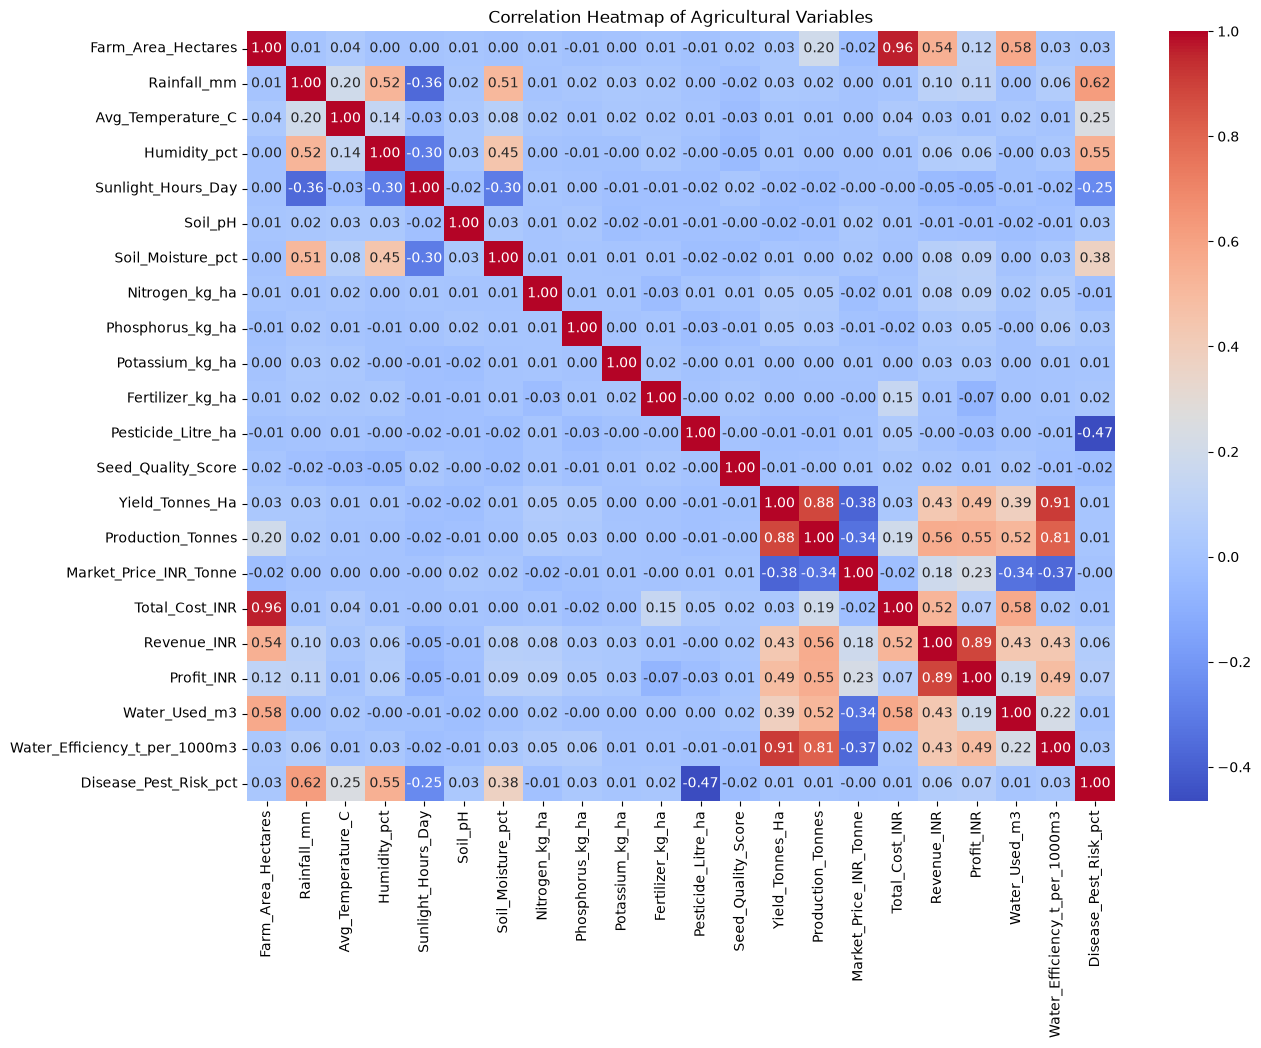

In [42]:
# Correlation heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Agricultural Variables')

plt.show()

In [30]:
corr = df.corr(numeric_only=True)['Yield_Tonnes_Ha'].sort_values(ascending=False)

print(corr[['Water_Efficiency_t_per_1000m3',
            'Production_Tonnes',
            'Revenue_INR',
            'Rainfall_mm']])

Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Revenue_INR                      0.433648
Rainfall_mm                      0.030853
Name: Yield_Tonnes_Ha, dtype: float64


In [31]:
# Correlation Analysis

yield_corr = df.corr(numeric_only=True)['Yield_Tonnes_Ha'].sort_values(ascending=False)

print("Correlation with Crop Yield:")
print(yield_corr[['Water_Efficiency_t_per_1000m3',
                  'Production_Tonnes',
                  'Revenue_INR',
                  'Rainfall_mm']])

Correlation with Crop Yield:
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Revenue_INR                      0.433648
Rainfall_mm                      0.030853
Name: Yield_Tonnes_Ha, dtype: float64


In [32]:
# Correlation Analysis

yield_corr = df.corr(numeric_only=True)['Yield_Tonnes_Ha'].sort_values(ascending=False)

print("Correlation with Crop Yield:")
print(yield_corr[['Water_Efficiency_t_per_1000m3',
                  'Production_Tonnes',
                  'Revenue_INR',
                  'Rainfall_mm']])

Correlation with Crop Yield:
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Revenue_INR                      0.433648
Rainfall_mm                      0.030853
Name: Yield_Tonnes_Ha, dtype: float64


In [37]:
# Key Relationships

print("Revenue vs Profit:",
      df['Revenue_INR'].corr(df['Profit_INR']))

print("Water Efficiency vs Yield:",
      df['Water_Efficiency_t_per_1000m3'].corr(df['Yield_Tonnes_Ha']))

print("Production vs Yield:",
      df['Production_Tonnes'].corr(df['Yield_Tonnes_Ha']))

print("Rainfall vs Yield:",
      df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha']))

Revenue vs Profit: 0.8873306756987913
Water Efficiency vs Yield: 0.9154379390632494
Production vs Yield: 0.8851711011220613
Rainfall vs Yield: 0.03085301698272096


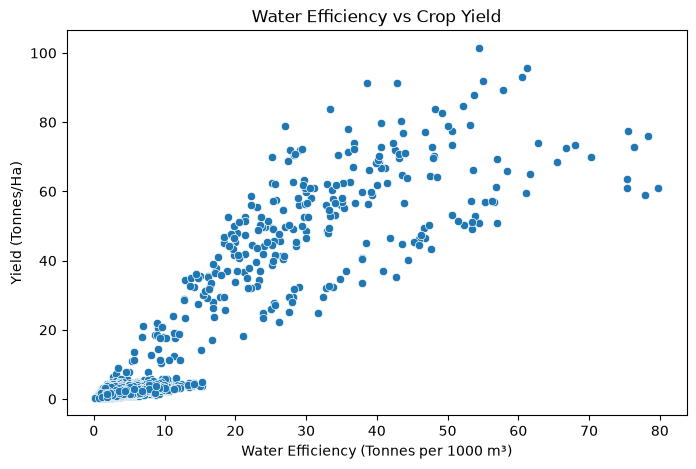

In [3]:
# Relationship between water efficiency and yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Yield_Tonnes_Ha'
)

plt.title('Water Efficiency vs Crop Yield')
plt.xlabel('Water Efficiency (Tonnes per 1000 m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

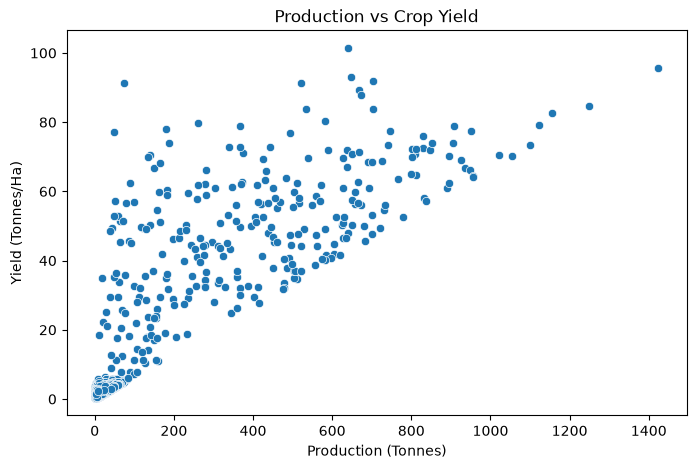

In [4]:
# Relationship between production and yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Production_Tonnes',
    y='Yield_Tonnes_Ha'
)

plt.title('Production vs Crop Yield')
plt.xlabel('Production (Tonnes)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

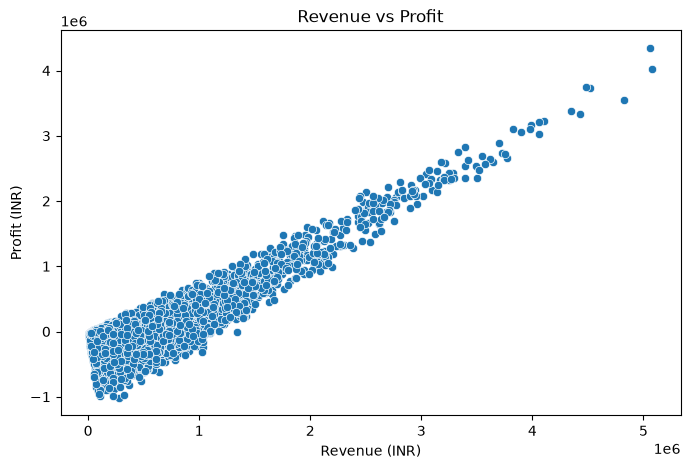

In [5]:
# Relationship between revenue and profit

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Revenue_INR',
    y='Profit_INR'
)

plt.title('Revenue vs Profit')
plt.xlabel('Revenue (INR)')
plt.ylabel('Profit (INR)')

plt.show()

In [6]:
# Average yield by crop and season

crop_season_yield = (
    df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha']
    .mean()
    .reset_index()
)

print(crop_season_yield)

    Season       Crop  Yield_Tonnes_Ha
0   Kharif     Chilli         1.731413
1   Kharif     Cotton         1.372804
2   Kharif  Groundnut         1.483646
3   Kharif      Maize         2.966410
4   Kharif     Pulses         1.036063
5   Kharif       Rice         2.707621
6   Kharif  Sugarcane        53.459120
7   Kharif      Wheat         2.255430
8     Rabi     Chilli         1.461615
9     Rabi     Cotton         1.192915
10    Rabi  Groundnut         1.221445
11    Rabi      Maize         2.614913
12    Rabi     Pulses         0.871887
13    Rabi       Rice         2.333680
14    Rabi  Sugarcane        43.940394
15    Rabi      Wheat         2.058814
16    Zaid     Chilli         1.177742
17    Zaid     Cotton         0.951648
18    Zaid  Groundnut         1.037778
19    Zaid      Maize         2.297590
20    Zaid     Pulses         0.652131
21    Zaid       Rice         1.900490
22    Zaid  Sugarcane        38.423922
23    Zaid      Wheat         1.748588


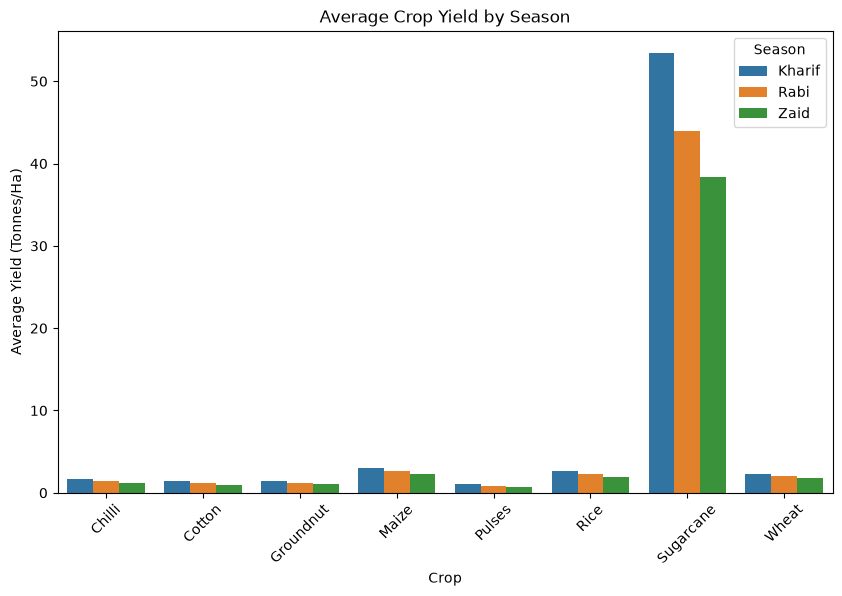

In [7]:
# Crop-wise yield comparison across seasons

plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_season_yield,
    x='Crop',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)

plt.show()

In [8]:
# Average profit by crop and season

crop_season_profit = (
    df.groupby(['Season', 'Crop'])['Profit_INR']
    .mean()
    .reset_index()
)

print(crop_season_profit)

    Season       Crop    Profit_INR
0   Kharif     Chilli  9.543804e+05
1   Kharif     Cotton  2.169995e+05
2   Kharif  Groundnut  1.082654e+05
3   Kharif      Maize -3.933267e+04
4   Kharif     Pulses  4.333890e+04
5   Kharif       Rice -6.490340e+04
6   Kharif  Sugarcane  1.000791e+06
7   Kharif      Wheat -1.058719e+05
8     Rabi     Chilli  6.385725e+05
9     Rabi     Cotton  1.073436e+05
10    Rabi  Groundnut  1.041654e+04
11    Rabi      Maize -8.913340e+04
12    Rabi     Pulses -1.430914e+04
13    Rabi       Rice -9.842787e+04
14    Rabi  Sugarcane  7.316129e+05
15    Rabi      Wheat -1.199546e+05
16    Zaid     Chilli  4.486591e+05
17    Zaid     Cotton -5.392534e+04
18    Zaid  Groundnut -6.887250e+04
19    Zaid      Maize -1.940492e+05
20    Zaid     Pulses -1.392278e+05
21    Zaid       Rice -2.272393e+05
22    Zaid  Sugarcane  5.836358e+05
23    Zaid      Wheat -1.932090e+05


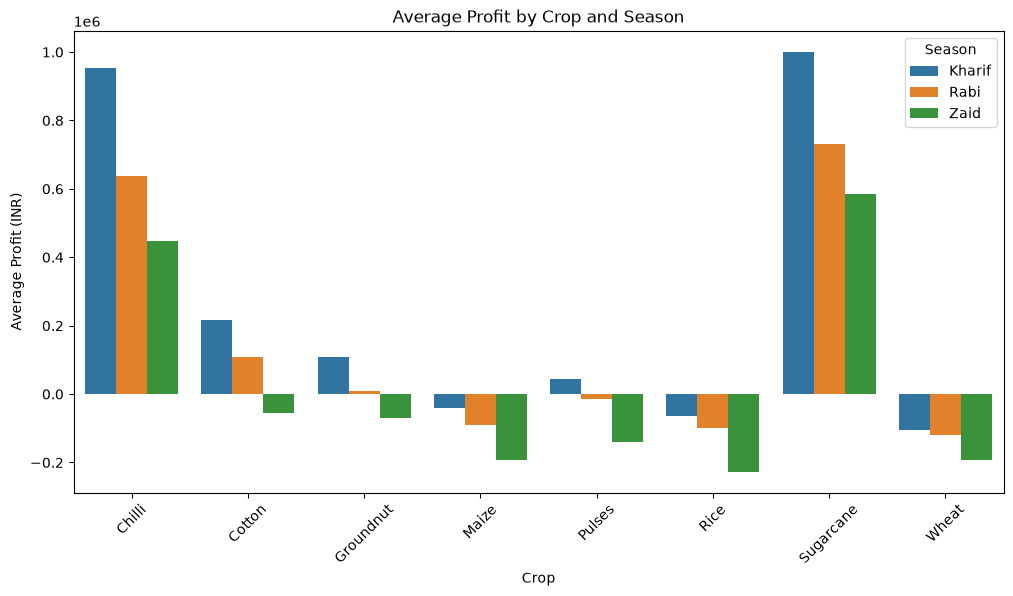

In [9]:
# Average profit by crop and season

plt.figure(figsize=(12, 6))

sns.barplot(
    data=crop_season_profit,
    x='Crop',
    y='Profit_INR',
    hue='Season'
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.show()

In [10]:
# Crop + Season Profit Analysis

profit_pivot = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
)

print(profit_pivot)

Season           Kharif           Rabi           Zaid
Crop                                                 
Chilli     9.543804e+05  638572.496933  448659.093750
Cotton     2.169995e+05  107343.587065  -53925.336957
Groundnut  1.082654e+05   10416.542373  -68872.500000
Maize     -3.933267e+04  -89133.403433 -194049.166667
Pulses     4.333890e+04  -14309.136150 -139227.806452
Rice      -6.490340e+04  -98427.868613 -227239.343137
Sugarcane  1.000791e+06  731612.860465  583635.803922
Wheat     -1.058719e+05 -119954.565401 -193208.952941


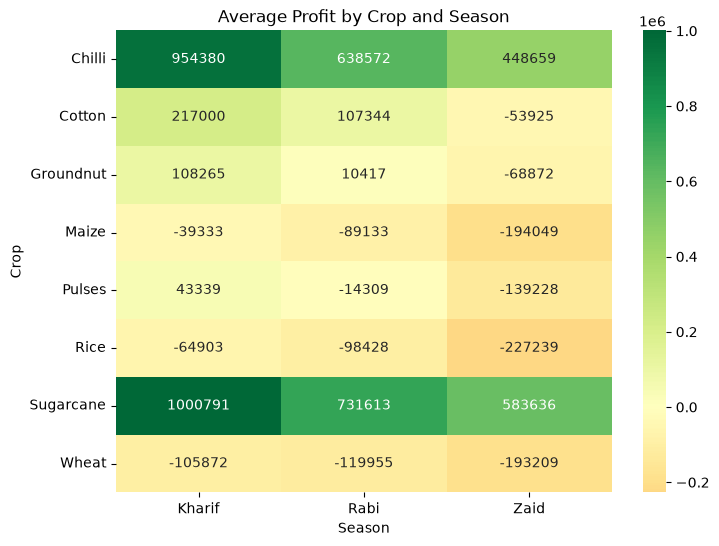

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    profit_pivot,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

In [12]:
yield_pivot = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)

print(yield_pivot)

Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.731413   1.461615   1.177742
Cotton      1.372804   1.192915   0.951648
Groundnut   1.483646   1.221445   1.037778
Maize       2.966410   2.614913   2.297590
Pulses      1.036063   0.871887   0.652131
Rice        2.707621   2.333680   1.900490
Sugarcane  53.459120  43.940394  38.423922
Wheat       2.255430   2.058814   1.748588


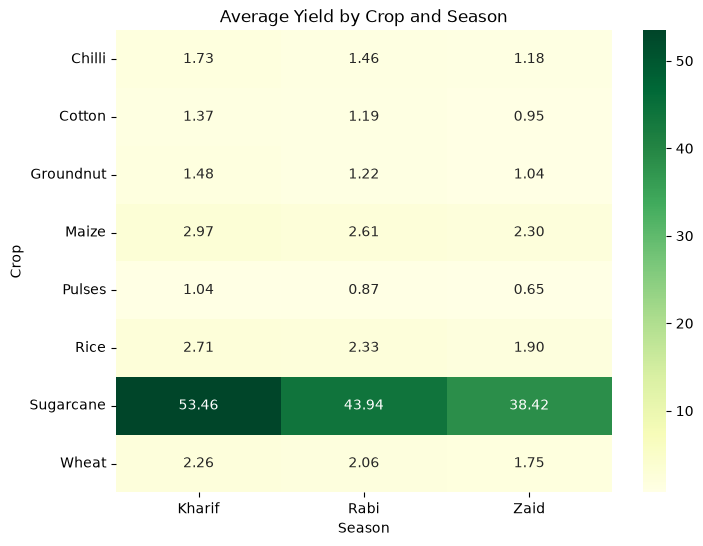

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    yield_pivot,
    annot=True,
    fmt='.2f',
    cmap='YlGn'
)

plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

In [14]:
best_combination = (
    df.groupby(['Crop', 'Season'])['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print("Top Crop + Season combinations:")
print(best_combination.head(10))

Top Crop + Season combinations:
Crop       Season
Sugarcane  Kharif    1.000791e+06
Chilli     Kharif    9.543804e+05
Sugarcane  Rabi      7.316129e+05
Chilli     Rabi      6.385725e+05
Sugarcane  Zaid      5.836358e+05
Chilli     Zaid      4.486591e+05
Cotton     Kharif    2.169995e+05
Groundnut  Kharif    1.082654e+05
Cotton     Rabi      1.073436e+05
Pulses     Kharif    4.333890e+04
Name: Profit_INR, dtype: float64


In [15]:
print("Lowest Crop + Season combinations:")
print(best_combination.tail(10))

Lowest Crop + Season combinations:
Crop       Season
Rice       Kharif    -64903.404459
Groundnut  Zaid      -68872.500000
Maize      Rabi      -89133.403433
Rice       Rabi      -98427.868613
Wheat      Kharif   -105871.869863
           Rabi     -119954.565401
Pulses     Zaid     -139227.806452
Wheat      Zaid     -193208.952941
Maize      Zaid     -194049.166667
Rice       Zaid     -227239.343137
Name: Profit_INR, dtype: float64


In [16]:
# Best Crop Selection Analysis

crop_performance = (
    df.groupby('Crop')[
        ['Profit_INR',
         'Yield_Tonnes_Ha',
         'Water_Efficiency_t_per_1000m3']
    ]
    .mean()
    .sort_values('Profit_INR', ascending=False)
)

print(crop_performance)

              Profit_INR  Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3
Crop                                                                    
Sugarcane  817187.986885        46.938746                      30.477672
Chilli     750878.342233         1.540344                       2.947709
Cotton     124546.915354         1.225734                       1.938016
Groundnut   44858.120283         1.317924                       3.154795
Pulses      -4238.052419         0.918198                       2.896504
Maize      -83978.326679         2.717130                       5.602995
Rice      -102213.504348         2.439413                       1.946112
Wheat     -123398.337134         2.109216                       4.628393


In [17]:
# Normalize the performance measures

normalized = (
    crop_performance - crop_performance.min()
) / (
    crop_performance.max() - crop_performance.min()
)

print(normalized)

           Profit_INR  Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3
Crop                                                                 
Sugarcane    1.000000         1.000000                       1.000000
Chilli       0.929502         0.013519                       0.035379
Cotton       0.263607         0.006683                       0.000000
Groundnut    0.178885         0.008686                       0.042635
Pulses       0.126687         0.000000                       0.033584
Maize        0.041910         0.039090                       0.128417
Rice         0.022523         0.033055                       0.000284
Wheat        0.000000         0.025880                       0.094268


In [18]:
# Calculate overall crop performance score

normalized['Overall_Score'] = (
    normalized['Profit_INR'] +
    normalized['Yield_Tonnes_Ha'] +
    normalized['Water_Efficiency_t_per_1000m3']
) / 3

normalized = normalized.sort_values(
    'Overall_Score',
    ascending=False
)

print("Overall Crop Performance:")
print(normalized[['Overall_Score']])

Overall Crop Performance:
           Overall_Score
Crop                    
Sugarcane       1.000000
Chilli          0.326133
Cotton          0.090097
Groundnut       0.076735
Maize           0.069806
Pulses          0.053424
Wheat           0.040049
Rice            0.018621


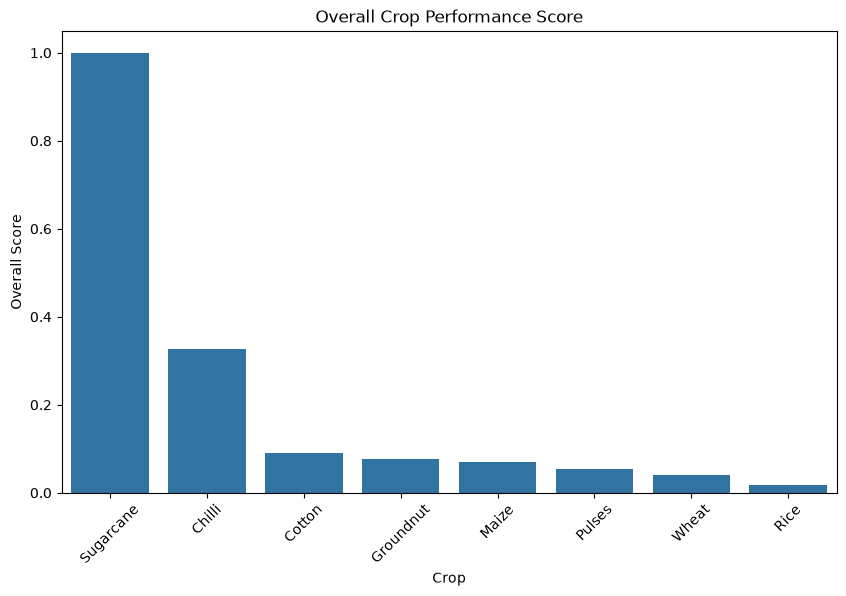

In [19]:
# Overall crop performance

plt.figure(figsize=(10, 6))

sns.barplot(
    x=normalized.index,
    y=normalized['Overall_Score']
)

plt.title('Overall Crop Performance Score')
plt.xlabel('Crop')
plt.ylabel('Overall Score')
plt.xticks(rotation=45)

plt.show()

In [20]:
# Identify the best performing crop

best_crop = normalized['Overall_Score'].idxmax()
best_score = normalized['Overall_Score'].max()

print("Best Performing Crop:", best_crop)
print("Overall Score:", round(best_score, 2))

Best Performing Crop: Sugarcane
Overall Score: 1.0


In [21]:
# Best Crop + Season combination

best_combination = (
    df.groupby(['Crop', 'Season'])['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print("Best Crop + Season:")
print(best_combination.head(10))

Best Crop + Season:
Crop       Season
Sugarcane  Kharif    1.000791e+06
Chilli     Kharif    9.543804e+05
Sugarcane  Rabi      7.316129e+05
Chilli     Rabi      6.385725e+05
Sugarcane  Zaid      5.836358e+05
Chilli     Zaid      4.486591e+05
Cotton     Kharif    2.169995e+05
Groundnut  Kharif    1.082654e+05
Cotton     Rabi      1.073436e+05
Pulses     Kharif    4.333890e+04
Name: Profit_INR, dtype: float64


In [22]:
# Worst Crop + Season combinations

print("Worst Crop + Season:")
print(best_combination.tail(10))

Worst Crop + Season:
Crop       Season
Rice       Kharif    -64903.404459
Groundnut  Zaid      -68872.500000
Maize      Rabi      -89133.403433
Rice       Rabi      -98427.868613
Wheat      Kharif   -105871.869863
           Rabi     -119954.565401
Pulses     Zaid     -139227.806452
Wheat      Zaid     -193208.952941
Maize      Zaid     -194049.166667
Rice       Zaid     -227239.343137
Name: Profit_INR, dtype: float64


In [23]:
# Best season for each crop

best_season_crop = (
    df.groupby(['Crop', 'Season'])['Profit_INR']
    .mean()
    .reset_index()
)

best_season_crop = best_season_crop.loc[
    best_season_crop.groupby('Crop')['Profit_INR'].idxmax()
]

print("Best Season for Each Crop:")
print(best_season_crop.sort_values('Profit_INR', ascending=False))

Best Season for Each Crop:
         Crop  Season    Profit_INR
18  Sugarcane  Kharif  1.000791e+06
0      Chilli  Kharif  9.543804e+05
3      Cotton  Kharif  2.169995e+05
6   Groundnut  Kharif  1.082654e+05
12     Pulses  Kharif  4.333890e+04
9       Maize  Kharif -3.933267e+04
15       Rice  Kharif -6.490340e+04
21      Wheat  Kharif -1.058719e+05


In [24]:
# Final crop recommendations

recommendation = best_season_crop[
    ['Crop', 'Season', 'Profit_INR']
].sort_values('Profit_INR', ascending=False)

print("Final Crop + Season Recommendations:")
print(recommendation)

Final Crop + Season Recommendations:
         Crop  Season    Profit_INR
18  Sugarcane  Kharif  1.000791e+06
0      Chilli  Kharif  9.543804e+05
3      Cotton  Kharif  2.169995e+05
6   Groundnut  Kharif  1.082654e+05
12     Pulses  Kharif  4.333890e+04
9       Maize  Kharif -3.933267e+04
15       Rice  Kharif -6.490340e+04
21      Wheat  Kharif -1.058719e+05


In [25]:
# Average profit by season

season_profit = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by Season:")
print(season_profit)

Average Profit by Season:
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


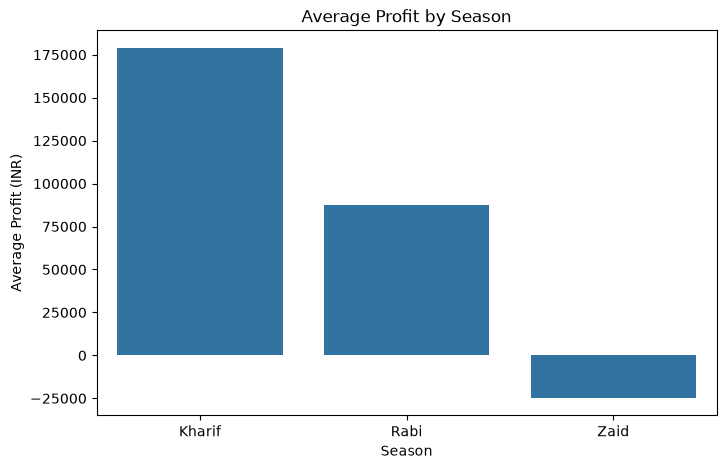

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

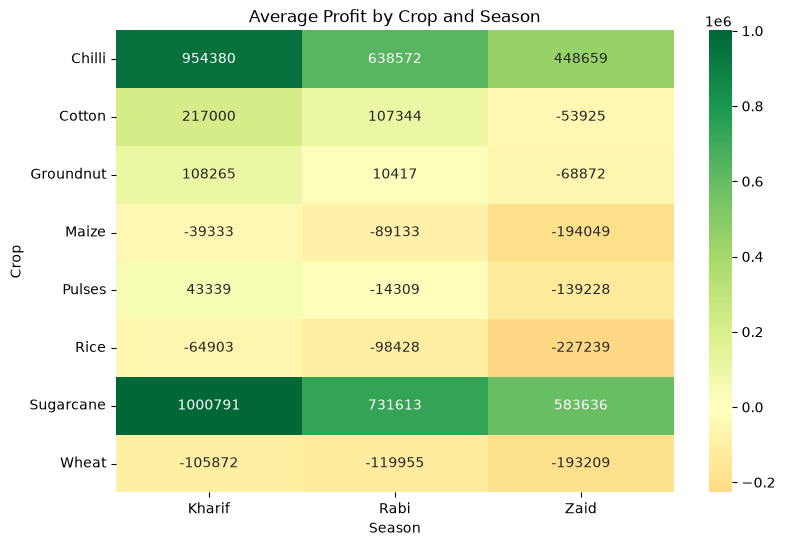

In [27]:
# Crop + Season Profit Heatmap

plt.figure(figsize=(9, 6))

profit_pivot = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
)

sns.heatmap(
    profit_pivot,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

Conclusion 
The agricultural data analysis shows that crop performance varies significantly across crops and seasons. Based on the combined performance score of profit, yield, and water efficiency, Sugarcane is the best-performing crop, with an overall score of 1.00.

The Kharif season is the most profitable season, with an average profit of approximately ₹178,914.65, followed by Rabi at approximately ₹87,689.47. Zaid has a negative average profit of approximately −₹24,084.82.

The best crop-season combination is Sugarcane in Kharif, with an average profit of approximately ₹10,00,791. Chilli in Kharif is the second-best combination, with an average profit of approximately ₹9,54,380.

The correlation analysis shows a very strong positive relationship between water efficiency and crop yield (0.912568). In contrast, rainfall has only a very weak linear relationship with yield (0.030951). This indicates that improving water efficiency may be more strongly associated with higher yield than rainfall alone in this dataset.

Overall, the analysis suggests that selecting suitable crops and seasons, improving water-use efficiency, and reviewing the costs and profitability of low-performing crops can help support better agricultural production and profitability decisions.